# 01 Data Download, Cache, and EDA

Download US/UK index data from Yahoo Finance, cache normalized OHLCV files locally, and create basic exploratory charts.

In [1]:
# Project configuration and reproducibility
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    SEED,
    START_DATE,
    END_DATE,
    TRAIN_END_DATE,
    TICKERS,
    CACHE_DIR,
    RESULTS_DIR,
    CHARTS_DIR,
    TRANSACTION_COST,
    set_global_seed,
    ensure_directories,
)

set_global_seed(SEED)
ensure_directories()
print(f"Configured {len(TICKERS)} US/UK indices from {START_DATE} to {END_DATE} with seed={SEED}.")


Configured 7 US/UK indices from 2013-01-01 to 2023-01-01 with seed=42.


## Build execution note

These notebooks were rebuilt from scratch with clean metadata and empty outputs. Live data execution was not completed during repository build because the sandbox could not resolve Yahoo Finance hosts. After installing `requirements.txt` in a normal networked environment, run the notebooks in order from `01_data.ipynb` to `04_combined_model.ipynb`.

In [2]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

from src.backtest import prepare_price_frame

plt.style.use("seaborn-v0_8-whitegrid")


In [3]:
def cache_name(symbol: str) -> str:
    cleaned = re.sub(r"[^A-Za-z0-9]+", "_", symbol).strip("_")
    return f"{cleaned}.csv"


def download_index(name: str, symbol: str) -> pd.DataFrame:
    cache_path = CACHE_DIR / cache_name(symbol)
    if cache_path.exists():
        cached = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        return cached

    raw = yf.download(
        symbol,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
        actions=False,
        threads=False,
    )
    if raw.empty:
        raise RuntimeError(
            f"No data returned for {name} ({symbol}). Check network access and yfinance version."
        )

    frame = prepare_price_frame(raw)
    frame.to_csv(cache_path)
    return frame


In [4]:
price_data = {}
failures = {}

for name, symbol in TICKERS.items():
    try:
        price_data[name] = download_index(name, symbol)
        print(f"{name}: {len(price_data[name]):,} rows cached")
    except Exception as exc:
        failures[name] = str(exc)
        print(f"{name}: FAILED - {exc}")

if failures:
    print("\nDownload failures:")
    for name, error in failures.items():
        print(f"- {name}: {error}")

if not price_data:
    raise RuntimeError("No market data is available. Re-run with network access before executing later notebooks.")


S&P 500: 2,517 rows cached


Dow Jones Industrial Average: 2,517 rows cached


NASDAQ Composite: 2,517 rows cached


Russell 2000: 2,517 rows cached


FTSE 100: 2,525 rows cached


Cboe UK 100: 2,529 rows cached


Cboe Volatility Index: 2,517 rows cached


In [5]:
summary_rows = []
for name, frame in price_data.items():
    summary_rows.append(
        {
            "index": name,
            "symbol": TICKERS[name],
            "first_date": frame.index.min().date(),
            "last_date": frame.index.max().date(),
            "rows": len(frame),
            "daily_return_mean": frame["returns"].mean(),
            "daily_return_std": frame["returns"].std(),
        }
    )

eda_summary = pd.DataFrame(summary_rows)
eda_summary.to_csv(RESULTS_DIR / "data_summary.csv", index=False)
eda_summary


,index,symbol,first_date,last_date,rows,daily_return_mean,daily_return_std
0,S&P 500,^GSPC,2013-01-03,2022-12-30,2517,0.000383,0.011116
1,Dow Jones Industrial Average,^DJI,2013-01-03,2022-12-30,2517,0.000359,0.011014
2,NASDAQ Composite,^IXIC,2013-01-03,2022-12-30,2517,0.000482,0.013053
3,Russell 2000,^RUT,2013-01-03,2022-12-30,2517,0.000279,0.014027
4,FTSE 100,^FTSE,2013-01-03,2022-12-30,2525,0.000084,0.010027
5,Cboe UK 100,^BUK100P,2013-01-03,2022-12-30,2529,0.000086,0.009977
6,Cboe Volatility Index,^VIX,2013-01-03,2022-12-30,2517,0.000155,0.080044


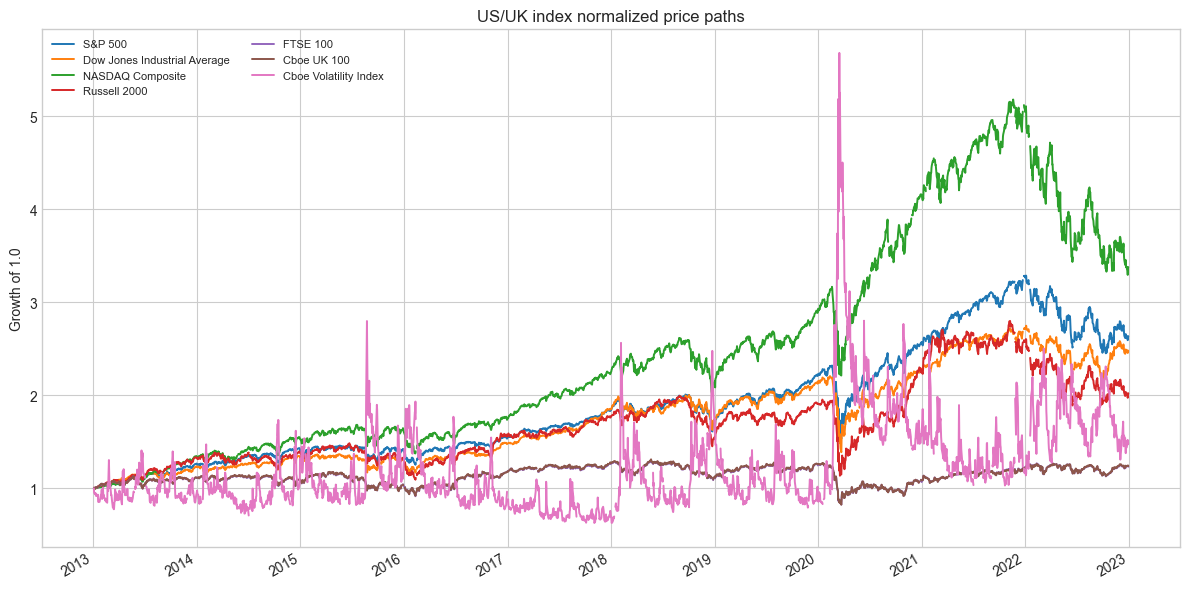

In [6]:
prices = pd.concat(
    {name: frame["adj_close"] for name, frame in price_data.items()},
    axis=1,
).dropna(how="all")

normalized = prices.apply(lambda series: series / series.dropna().iloc[0])
fig, ax = plt.subplots(figsize=(12, 6))
normalized.plot(ax=ax, linewidth=1.4)
ax.set_title("US/UK index normalized price paths")
ax.set_ylabel("Growth of 1.0")
ax.set_xlabel("")
ax.legend(loc="upper left", ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "price_paths.png", dpi=160)
plt.show()


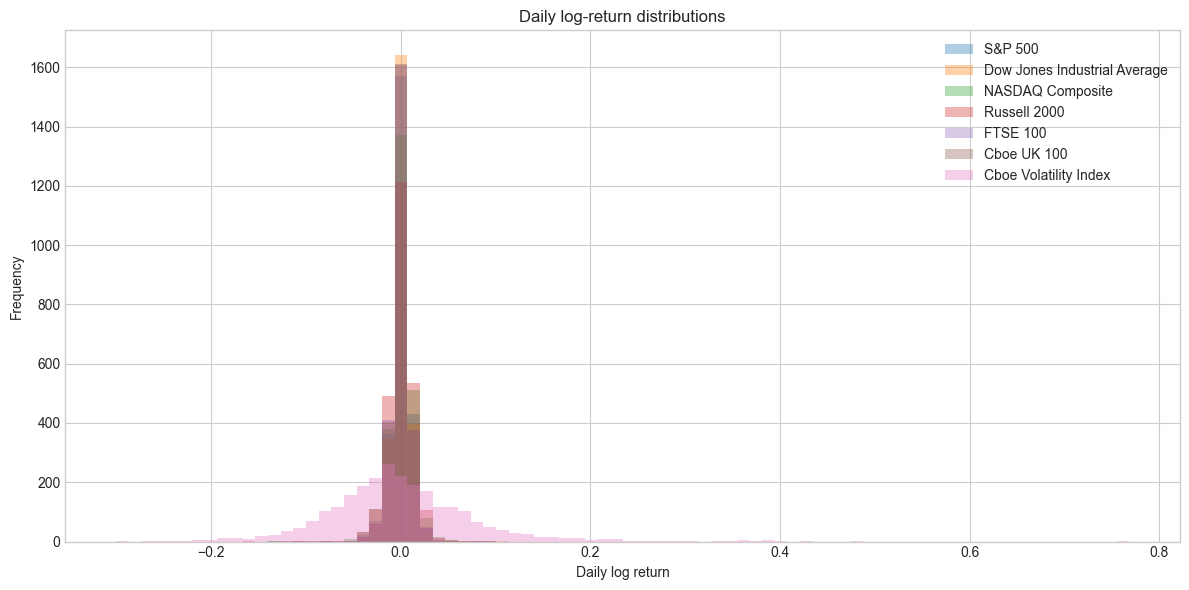

In [7]:
returns = pd.concat(
    {name: frame["returns"] for name, frame in price_data.items()},
    axis=1,
).dropna(how="all")

fig, ax = plt.subplots(figsize=(12, 6))
returns.plot(kind="hist", bins=80, alpha=0.35, ax=ax)
ax.set_title("Daily log-return distributions")
ax.set_xlabel("Daily log return")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "return_distributions.png", dpi=160)
plt.show()
